In [ ]:
pip install pyzbar


In [ ]:
get_ipython().system('apt-get update')
get_ipython().system('apt-get install -y libzbar0')

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:6 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 1s (3,065 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libzbar0 is already the newest version (0.23.92-4b

Sweep 01 | Energy: -4693.60 | Acc: 0.8808 | Mean Pixel: -0.0576
Sweep 02 | Energy: -4875.20 | Acc: 0.9004 | Mean Pixel: -0.0392
Sweep 03 | Energy: -4953.60 | Acc: 0.9156 | Mean Pixel: -0.0584
Sweep 04 | Energy: -4931.20 | Acc: 0.9156 | Mean Pixel: -0.0472
Sweep 05 | Energy: -4959.20 | Acc: 0.9184 | Mean Pixel: -0.0464
Sweep 06 | Energy: -4951.20 | Acc: 0.9136 | Mean Pixel: -0.0400
Sweep 07 | Energy: -4959.20 | Acc: 0.9168 | Mean Pixel: -0.0480
Sweep 08 | Energy: -4919.20 | Acc: 0.9136 | Mean Pixel: -0.0480
Sweep 09 | Energy: -4921.60 | Acc: 0.9180 | Mean Pixel: -0.0712
Sweep 10 | Energy: -4962.40 | Acc: 0.9200 | Mean Pixel: -0.0704
Sweep 11 | Energy: -4980.00 | Acc: 0.9224 | Mean Pixel: -0.0592
Sweep 12 | Energy: -4940.80 | Acc: 0.9204 | Mean Pixel: -0.0616
Sweep 13 | Energy: -4958.40 | Acc: 0.9244 | Mean Pixel: -0.0616
Sweep 14 | Energy: -4958.40 | Acc: 0.9212 | Mean Pixel: -0.0568
Sweep 15 | Energy: -4944.00 | Acc: 0.9204 | Mean Pixel: -0.0440
Sweep 16 | Energy: -4932.00 | Acc: 0.916

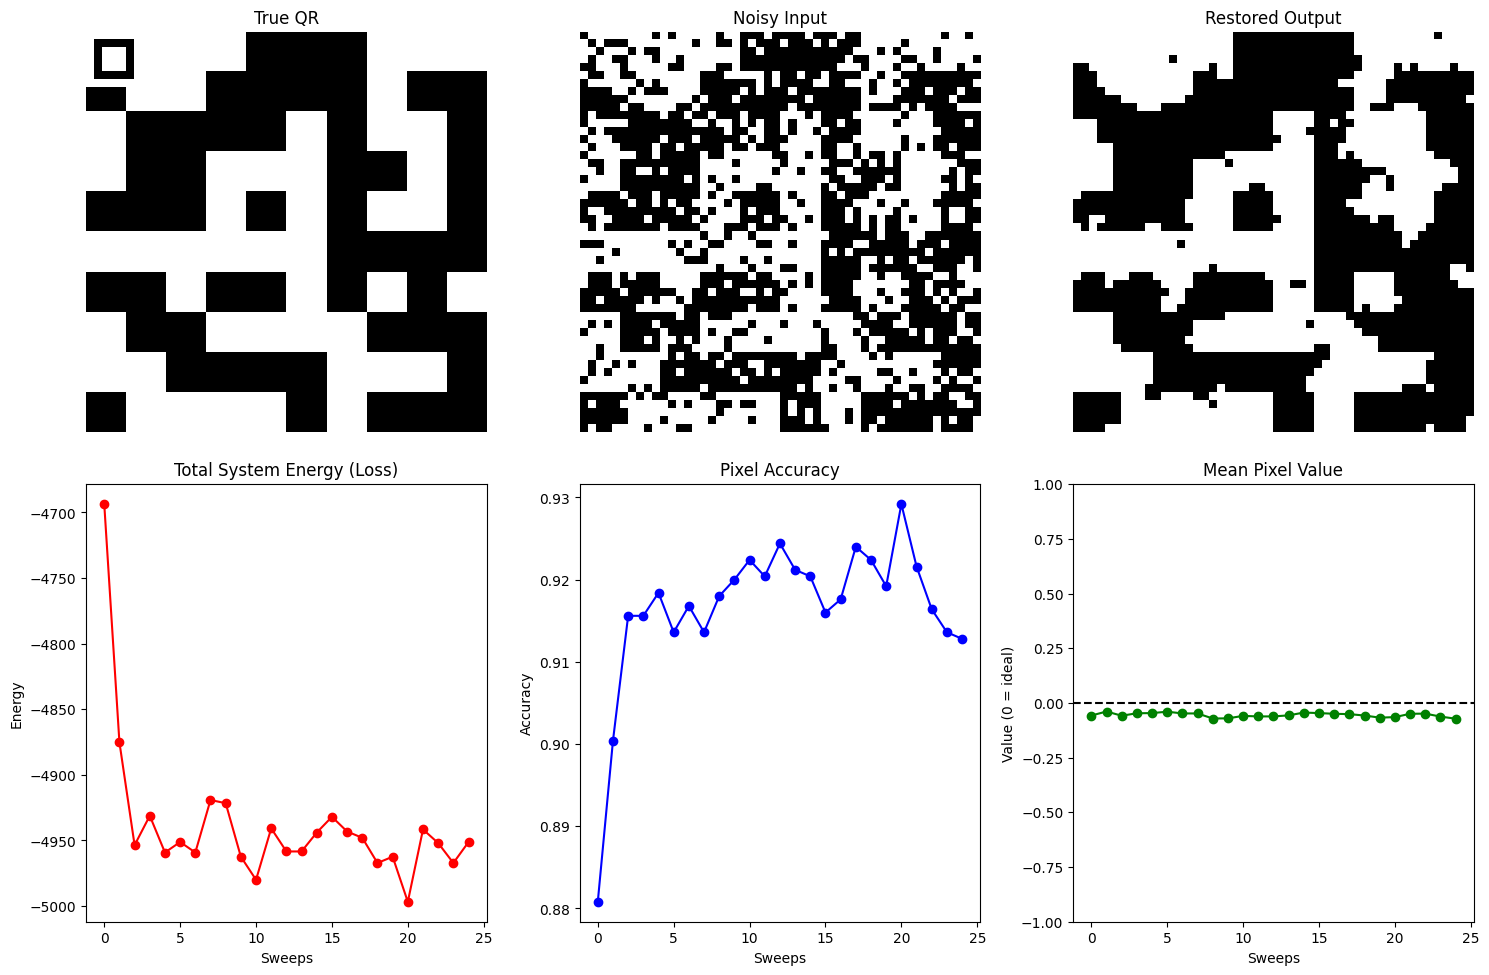

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pyzbar.pyzbar import decode
from PIL import Image



def generate_synthetic_qr(size=50, block_size=5):
    # 1. Initialization of a 50x50 black qr (all -1s)
    Z = -np.ones((size, size), dtype=int)

    # 2. Stochastic Block Generation
    np.random.seed(42)
    for i in range(0, size, block_size):
        for j in range(0, size, block_size):
            if np.random.rand() > 0.5:
                Z[i:i+block_size, j:j+block_size] = 1

    # 3. Alignment squares (finders)
    Z[0:7, 0:7] = 1
    Z[1:6, 1:6] = -1
    Z[2:5, 2:5] = 1

    return Z

def add_binary_noise(Z, flip_probability=0.20):
    random_matrix = np.random.rand(*Z.shape)
    flip_mask = random_matrix < flip_probability
    X = Z.copy()
    X[flip_mask] *= -1
    return X



def calculate_system_energy(X, Z, beta, eta):

    likelihood_energy = -eta * np.sum(X * Z)

    vertical_neighbors = np.sum(Z[:-1, :] * Z[1:, :])
    horizontal_neighbors = np.sum(Z[:, :-1] * Z[:, 1:])
    prior_energy = -beta * (vertical_neighbors + horizontal_neighbors)

    return likelihood_energy + prior_energy

def check_skill_issue(Z):

    return np.mean(Z)

def calculate_pixel_accuracy(Z_pred, Z_true):

    return np.mean(Z_pred == Z_true)

def simulate_phone_scanner(Z_pred):

    image_array = np.where(Z_pred == 1, 255, 0).astype(np.uint8)
    pil_img = Image.fromarray(image_array)
    decoded_objects = decode(pil_img)

    if not decoded_objects:
        print("Scanner Result: FAILED. Structural integrity lost.")
        return False
    else:
        for obj in decoded_objects:
            print(f"Scanner Result: SUCCESS! Decoded Data: {obj.data.decode('utf-8')}")
        return True



def get_neighbors_sum(Z, i, j, size):
    neighbor_sum = 0
    if i > 0: neighbor_sum += Z[i-1, j]
    if i < size-1: neighbor_sum += Z[i+1, j]
    if j > 0: neighbor_sum += Z[i, j-1]
    if j < size-1: neighbor_sum += Z[i, j+1]
    return neighbor_sum

def run_gibbs_sampler_with_metrics(X, true_Z, num_sweeps=30, beta=0.8, eta=1.2):
    size = X.shape[0]
    Z = X.copy()

    energy_history = []
    mean_pixel_history = []
    accuracy_history = []

    for sweep in range(num_sweeps):
        for i in range(size):
            for j in range(size):
                neighbor_sum = get_neighbors_sum(Z, i, j, size)

                score_plus  = np.exp(eta * X[i,j] * (1) + beta * (1) * neighbor_sum)
                score_minus = np.exp(eta * X[i,j] * (-1) + beta * (-1) * neighbor_sum)

                p_plus = score_plus / (score_plus + score_minus)

                if np.random.rand() < p_plus:
                    Z[i, j] = 1
                else:
                    Z[i, j] = -1

        # Track metrics at the end of every sweep
        current_energy = calculate_system_energy(X, Z, beta, eta)
        energy_history.append(current_energy)

        skill_metric = check_skill_issue(Z)
        mean_pixel_history.append(skill_metric)

        current_acc = calculate_pixel_accuracy(Z, true_Z)
        accuracy_history.append(current_acc)

        print(f"Sweep {sweep+1:02d} | Energy: {current_energy:7.2f} | Acc: {current_acc:.4f} | Mean Pixel: {skill_metric:.4f}")

    # Final Evaluation
    print("\n--- Final Results ---")
    final_accuracy = calculate_pixel_accuracy(Z, true_Z)
    print(f"Final Pixel Accuracy: {final_accuracy * 100:.2f}%")
    simulate_phone_scanner(Z)

    return Z, energy_history, mean_pixel_history, accuracy_history



# 1. Generate Data
true_image_Z = generate_synthetic_qr()
noisy_image_X = add_binary_noise(true_image_Z, flip_probability=0.20)

# 2. Run the Sampler
restored_Z, e_hist, m_hist, a_hist = run_gibbs_sampler_with_metrics(
    noisy_image_X, true_image_Z, num_sweeps=25, beta=0.8, eta=1.2
)

# 3. Plot the final images and the metrics side-by-side
fig = plt.figure(figsize=(15, 10))

# Subplot 1: Images
ax1 = plt.subplot(2, 3, 1)
ax1.imshow(true_image_Z, cmap='gray')
ax1.set_title('True QR')
ax1.axis('off')

ax2 = plt.subplot(2, 3, 2)
ax2.imshow(noisy_image_X, cmap='gray')
ax2.set_title('Noisy Input')
ax2.axis('off')

ax3 = plt.subplot(2, 3, 3)
ax3.imshow(restored_Z, cmap='gray')
ax3.set_title('Restored Output')
ax3.axis('off')

# Subplot 2: Energy vs Sweeps (Burn-in Identification)
ax4 = plt.subplot(2, 3, 4)
ax4.plot(e_hist, color='red', marker='o')
ax4.set_title('Total System Energy (Loss)')
ax4.set_xlabel('Sweeps')
ax4.set_ylabel('Energy')

# Subplot 3: Pixel Accuracy vs Sweeps
ax5 = plt.subplot(2, 3, 5)
ax5.plot(a_hist, color='blue', marker='o')
ax5.set_title('Pixel Accuracy')
ax5.set_xlabel('Sweeps')
ax5.set_ylabel('Accuracy')

# Subplot 4: Mean Pixel Value (Skill Issue Detection)
ax6 = plt.subplot(2, 3, 6)
ax6.plot(m_hist, color='green', marker='o')
ax6.axhline(y=0, color='black', linestyle='--') # Ideal 50/50 balance
ax6.set_ylim(-1, 1)
ax6.set_title('Mean Pixel Value')
ax6.set_xlabel('Sweeps')
ax6.set_ylabel('Value (0 = ideal)')

plt.tight_layout()
plt.show()

## PROBLEM 2 IMPLMENTATION

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


def generate_social_network(num_humans=150, num_bots=150):

    sizes = [num_humans, num_bots]
    p_in = 0.08  # 8% chance to follow someone in your own group
    p_out = 0.01 # 1% chance to follow someone in the other group

    # Generate the graph
    G = nx.random_partition_graph(sizes, p_in, p_out, seed=42)

    # Assign true latent states (Y): First 150 are Humans (-1), next 150 are Bots (+1)
    true_Y = np.array([-1] * num_humans + [1] * num_bots)
    return G, true_Y

def add_platform_noise(true_Y, noise_level=0.20):
    """Simulates the platform's flawed detection algorithm (20% error rate)."""
    A = true_Y.copy()
    flip_mask = np.random.rand(len(true_Y)) < noise_level
    A[flip_mask] *= -1
    return A

def graph_gibbs_sampler(G, A, true_Y, num_sweeps=30, beta=0.8, eta=1.2):
    nodes = list(G.nodes())
    Y = A.copy() # Start guess as the noisy observation

    energy_history = []
    accuracy_history = []

    for sweep in range(num_sweeps):
        for i in nodes:
            # Look up neighbors in the adjacency list
            neighbors = list(G.neighbors(i))

            # Calculate Prior sum (Homophily)
            neighbor_sum = sum([Y[j] for j in neighbors])

            # Mathematical Tug-of-War
            score_plus  = np.exp(eta * A[i] * (1) + beta * (1) * neighbor_sum)
            score_minus = np.exp(eta * A[i] * (-1) + beta * (-1) * neighbor_sum)

            # Normalize to probability and flip coin
            p_plus = score_plus / (score_plus + score_minus)
            Y[i] = 1 if np.random.rand() < p_plus else -1

        # Metrics Tracking (End of Sweep)
        # 1. Pixel/Node Accuracy
        current_acc = np.mean(Y == true_Y)
        accuracy_history.append(current_acc)

        # 2. Total Energy (Cross-Validation Proxy)
        likelihood_energy = -eta * np.sum(A * Y)
        # Iterate edges to find prior energy
        prior_energy = -beta * sum([Y[u] * Y[v] for u, v in G.edges()])
        energy_history.append(likelihood_energy + prior_energy)

        print(f"Sweep {sweep+1} | Accuracy: {current_acc:.4f} | Energy: {energy_history[-1]:.2f}")

    return Y, accuracy_history, energy_history


G, true_Y = generate_social_network()
noisy_A = add_platform_noise(true_Y, noise_level=0.25) # 25% starting error

restored_Y, acc_hist, eng_hist = graph_gibbs_sampler(
    G, noisy_A, true_Y, num_sweeps=20, beta=0.5, eta=1.5
)

Sweep 1 | Accuracy: 0.8567 | Energy: -742.50
Sweep 2 | Accuracy: 0.9800 | Energy: -919.50
Sweep 3 | Accuracy: 0.9933 | Energy: -939.50
Sweep 4 | Accuracy: 0.9900 | Energy: -937.50
Sweep 5 | Accuracy: 0.9933 | Energy: -931.50
Sweep 6 | Accuracy: 0.9900 | Energy: -936.50
Sweep 7 | Accuracy: 0.9933 | Energy: -939.50
Sweep 8 | Accuracy: 0.9967 | Energy: -940.50
Sweep 9 | Accuracy: 0.9933 | Energy: -933.50
Sweep 10 | Accuracy: 0.9900 | Energy: -932.50
Sweep 11 | Accuracy: 0.9933 | Energy: -935.50
Sweep 12 | Accuracy: 1.0000 | Energy: -941.50
Sweep 13 | Accuracy: 0.9967 | Energy: -938.50
Sweep 14 | Accuracy: 0.9867 | Energy: -933.50
Sweep 15 | Accuracy: 1.0000 | Energy: -941.50
Sweep 16 | Accuracy: 0.9933 | Energy: -939.50
Sweep 17 | Accuracy: 0.9900 | Energy: -938.50
Sweep 18 | Accuracy: 0.9967 | Energy: -939.50
Sweep 19 | Accuracy: 0.9933 | Energy: -934.50
Sweep 20 | Accuracy: 1.0000 | Energy: -941.50


Calculating graph layout... (this might take a few seconds)


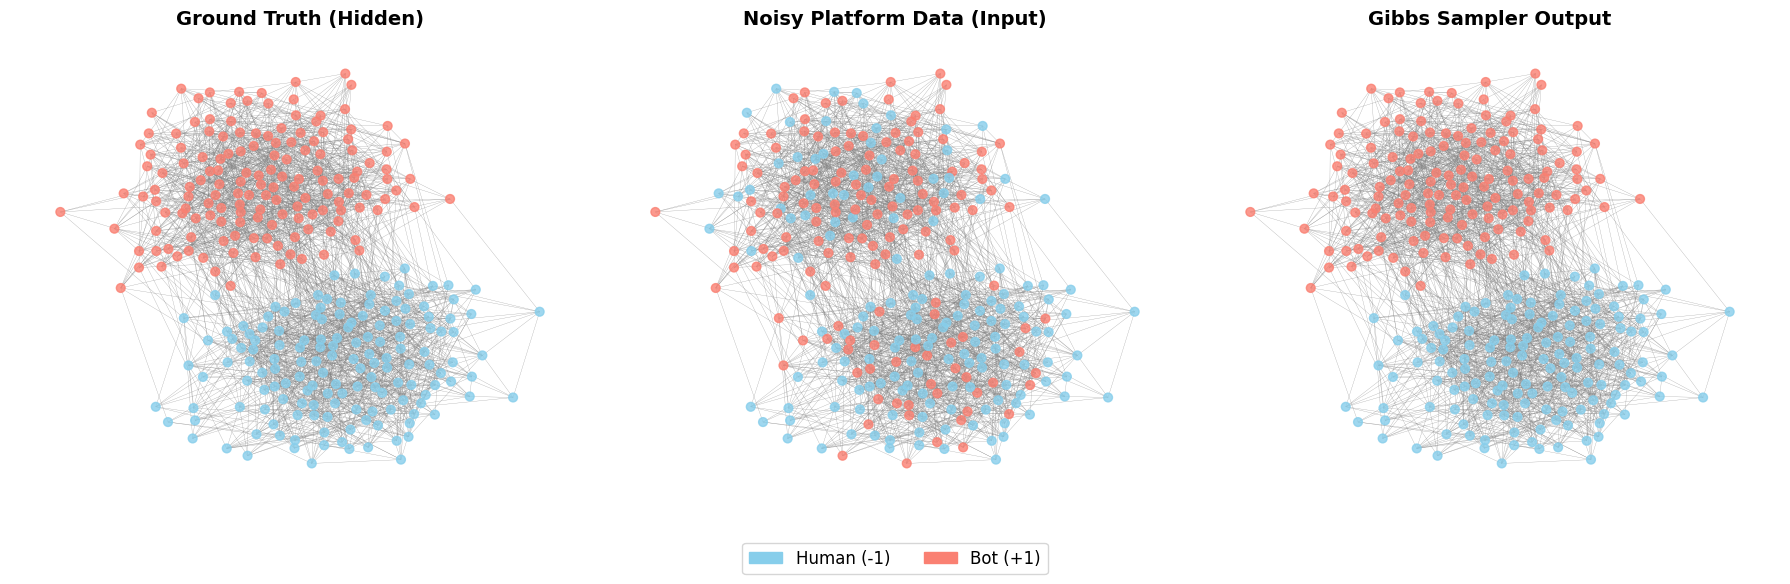

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualize_network_results(G, true_Y, noisy_A, restored_Y):

    print("Calculating graph layout... (this might take a few seconds)")
    # 1. Lock the Layout
    # spring_layout groups highly connected nodes together visually
    pos = nx.spring_layout(G, k=0.15, iterations=50, seed=42)

    # 2. Setup colors
    # -1 (Human) = SkyBlue, 1 (Bot) = Salmon Red
    color_map = {-1: 'skyblue', 1: 'salmon'}

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # --- Plot 1: The True Network ---
    colors_true = [color_map[true_Y[node]] for node in G.nodes()]
    nx.draw(G, pos, ax=axes[0], node_color=colors_true, node_size=40,
            edge_color='gray', alpha=0.8, width=0.2)
    axes[0].set_title('Ground Truth (Hidden)', fontsize=14, fontweight='bold')

    # --- Plot 2: The Noisy Observation ---
    colors_noisy = [color_map[noisy_A[node]] for node in G.nodes()]
    nx.draw(G, pos, ax=axes[1], node_color=colors_noisy, node_size=40,
            edge_color='gray', alpha=0.8, width=0.2)
    axes[1].set_title('Noisy Platform Data (Input)', fontsize=14, fontweight='bold')

    # --- Plot 3: The Gibbs Restored Network ---
    colors_restored = [color_map[restored_Y[node]] for node in G.nodes()]
    nx.draw(G, pos, ax=axes[2], node_color=colors_restored, node_size=40,
            edge_color='gray', alpha=0.8, width=0.2)
    axes[2].set_title('Gibbs Sampler Output', fontsize=14, fontweight='bold')

    # 3. Add a universal legend at the bottom
    human_patch = mpatches.Patch(color='skyblue', label='Human (-1)')
    bot_patch = mpatches.Patch(color='salmon', label='Bot (+1)')
    fig.legend(handles=[human_patch, bot_patch], loc='lower center',
               ncol=2, fontsize='large', bbox_to_anchor=(0.5, 0.02))

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15) # Make room for the legend
    plt.show()

# --- To use it, simply call this function at the very end of your script: ---
visualize_network_results(G, true_Y, noisy_A, restored_Y)